<h2>Problem 1</h2>
A logistics company ships natural gas over trains between different places. The places form the vertices of an undirected graph and each (bi-directional) edge between two vertices denotes a rail line over which fuel can be transported by train in either direction. We associate with each edge a cost/unit that specifies how much it costs to send one unit of oil between the two end points (in either direction). Some of the vertices are oil producing vertices where there is a net supply of oil whereas the other vertices are demand vertices where there is a net demand for oil. We will write demand as negative supply.

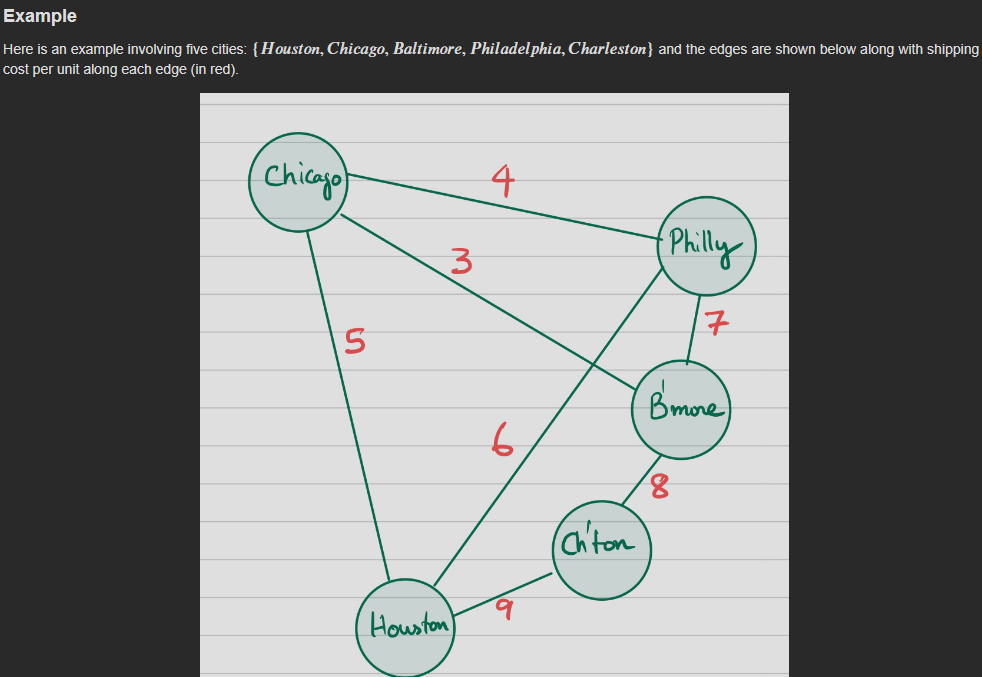

The following table summarizes the net supply (or demand) in metric tonnes for each city.

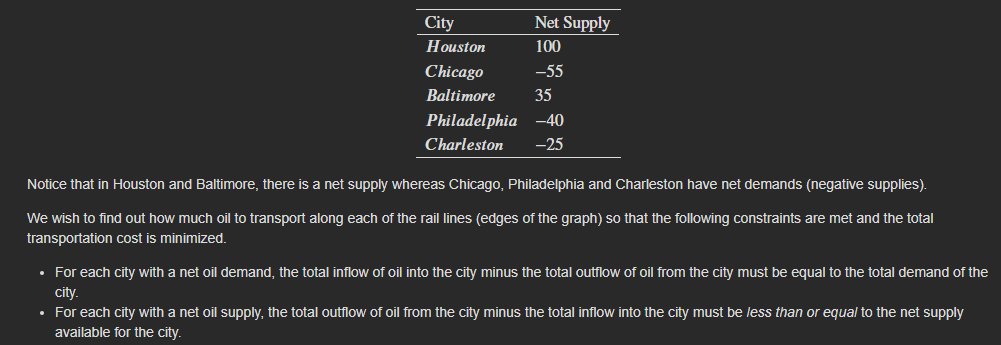

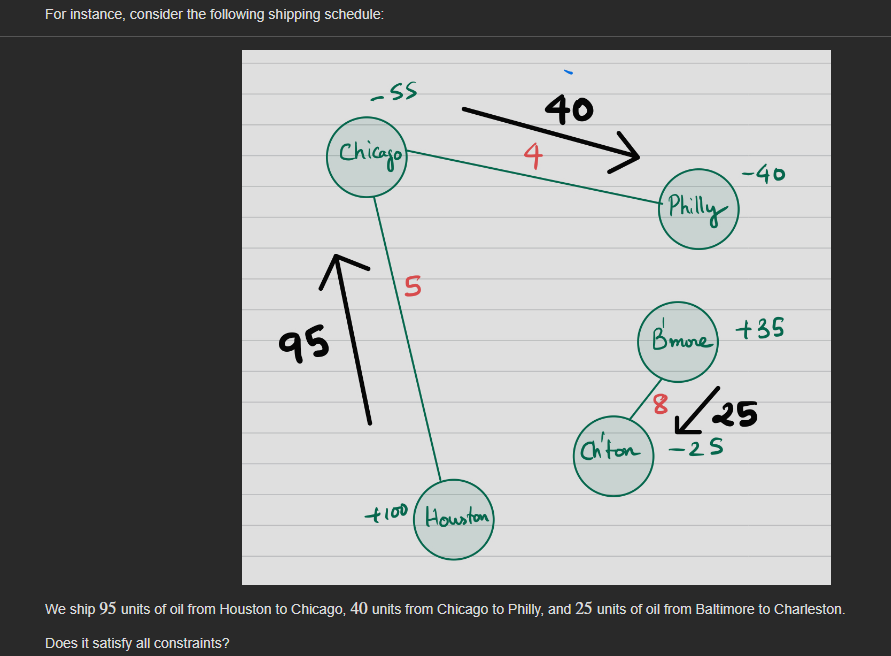





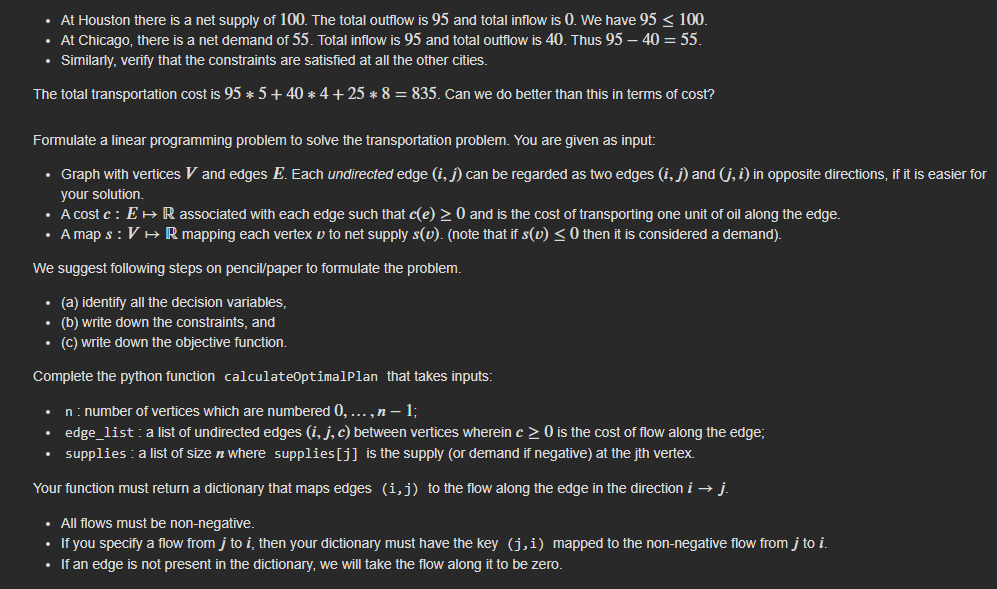


In [4]:
try:
    %load_ext autotime
except:
    !pip3 install ipython-autotime
    %load_ext autotime

try:
    %load_ext pulp
except:
    !pip3 install pulp

The pulp module is not an IPython extension.
time: 0 ns (started: 2024-11-29 20:33:32 -08:00)


In [25]:
from pulp import *
import re

def calculateOptimalPlan(n, edge_list, supplies, debug=False):
    assert n >= 1
    assert all( 0 <= i < n and 0 <= j < n and i != j and c >= 0 for (i,j,c) in edge_list)
    assert len(supplies) == n
    # assert all(supply!=0 for supply in supplies) # added by me

    # TODO: Formulate the LP for optimal transportation plan and return the solution as a dictionary
    #       from edges (i,j) to flow from i to j.
    #       If an edge is not present in the dictionary, we will take its flow to be zero.
    # your code here

    # create datastructures to facilitate algorithm
    cost_dict = {}
    __edges = {} # dictionary of edges incident on a vertex
    for (x,y,c) in edge_list:
        cost_dict[f'X_{x}_{y}'] = c
        cost_dict[f'X_{y}_{x}'] = c
        if x in __edges:
            if not(y  in __edges[x]):
                __edges[x].append(y)
        else:
            lst = [y]
            __edges[x] = lst
        if y in __edges:
            if not(x  in __edges[y]):
                __edges[y].append(x)
        else:
            lst = [x]
            __edges[y] = lst

    # Decision vars
    # X(u,v) = flow from u->v where u!=v and u={0,..,n-1} & v={0,..,n-1}. Flow >=0 & less than total of all postive supplies
    total_supply = sum(x for x in supplies if x>0)
    # lp_vars = [ LpVariable(f'X_{i}_{j}', 0.0, total_supply) if (i != j and i in __edges and j in __edges[i]) else None for j in range(n) for i in range(n) ]
    lp_vars = []
    lp_vars_dict= {}
    cost_dict= {}
    out_dict= {}
    for (u,v,c) in edge_list:
        var1 = LpVariable(f'X_{u}_{v}', 0.0, total_supply*2)
        var2 = LpVariable(f'X_{v}_{u}', 0.0, total_supply*2)
        cost_dict[f'X_{u}_{v}'] = c
        cost_dict[f'X_{v}_{u}'] = c
        lp_vars.append(var1)
        lp_vars.append(var2)
        lp_vars_dict[f'X_{u}_{v}'] = var1
        lp_vars_dict[f'X_{v}_{u}'] = var2

    # create the problem
    prob = LpProblem('XY', LpMinimize)

    #objective function - sum of all flows should be minimized
    objective_function = sum( var*cost_dict[var.name] for var in lp_vars)

    prob += objective_function

    #add constraints

    # total_in_flow - total_out_flow = demand for all vertices whose supply>0
    # incoming edges flow for vertex u is decision variable 'X_{?}_{u}'
    # outgoing edges flow for vertex u is decision variable 'X_{u}_{?}'
    for u in range(n):
        assert(u in __edges)
        u_str = str(u)
        total_incoming_flow = sum([var for var in lp_vars if(re.search(fr'^X_\d+_{u_str}$', var.name)) ])
        total_outgoing_flow = sum([var for var in lp_vars if(re.search(fr'^X_{u_str}_\d+$', var.name)) ])
        if supplies[u]<0: # demand
            prob += total_incoming_flow - total_outgoing_flow <= -supplies[u]
            prob += total_incoming_flow - total_outgoing_flow >= -supplies[u]
        elif supplies[u]>0: #supply
            prob += total_outgoing_flow - total_incoming_flow <= supplies[u]
        else: #demand=supply=0
            prob += total_outgoing_flow - total_incoming_flow <= 0

    # atleast one of x_{i}_{j} or x_{i}_{j} has to be zero 
    # (flow cannot happen both directions on an edge) - encoded as - y1+y2 <= max(y1,y2)
    for (u,v,c) in edge_list:
        prob += (1-lp_vars_dict[f'X_{v}_{u}']) + (1-lp_vars_dict[f'X_{u}_{v}']) <= 2
    status = prob.solve()
    assert status == constants.LpStatusOptimal, f'Unexpected non-optimal status {status}'
    for v in prob.variables():
        print(v.name, "=", v.varValue)

    for (u,v,c) in edge_list:
        var1 = f'X_{u}_{v}'
        var2 = f'X_{v}_{u}'
        if var1 in lp_vars_dict and lp_vars_dict[var1].varValue>0:
            out_dict[(u,v)] = lp_vars_dict[var1].varValue
        if var2 in lp_vars_dict and lp_vars_dict[var2].varValue>0:
            out_dict[(v,u)] = lp_vars_dict[var2].varValue
    return out_dict

In [20]:
def test_solution(n, edge_list, supplies, solution_map, expected_cost):
    cost = 0
    outflows = [0]*n
    inflows = [0]*n
    for (i,j,c) in edge_list:
        if (i,j) in solution_map: 
            flow = solution_map[(i,j)]
            cost += c * flow
            assert flow >= 0, f'flow on edge {(i,j)} is negative --> {flow}'
            outflows[i] += flow 
            inflows[j] += flow
        elif (j,i) in solution_map:
            flow = solution_map[(j,i)]
            cost += c * flow
            assert flow >= 0, f'flow on edge {(j,i)} in negative --> {flow}'
            outflows[j] += flow
            inflows[i] += flow 
    for (i, s) in enumerate(supplies):
        if s > 0:
            assert outflows[i]  - inflows[i] <= s, f'Vertex {i} constraint violated: total outflow = {outflows[i]} inflow = {inflows[i]}, supply = {s}'
        else:
            assert abs(inflows[i]-outflows[i] + s) <= 1E-2,f'Vertex{i} constraint violated: inflow = {inflows[i]} outflow={outflows[i]}, demand = {-s}'
    if expected_cost != None:
        assert abs(expected_cost - cost) <= 1E-02, f'Expected cost: {expected_cost}, your algorithm returned: {cost}'
    print('Test Passed!')

n = 5
edge_list = [
    (0,1, 5), (0, 3, 3), (0, 4, 4),
    (1,2, 9), (1,4, 6),
    (2,3,8),
    (3,4,7)
]
supplies = [-55, 100, -25, 35, -40]
sol_map = calculateOptimalPlan(n, edge_list, supplies, debug=True)
test_solution(n, edge_list, supplies, sol_map,670)


print('5 points!')

X_0_1 = 0.0
X_0_3 = 0.0
X_0_4 = 0.0
X_1_0 = 20.0
X_1_2 = 25.0
X_1_4 = 40.0
X_2_1 = 0.0
X_2_3 = 0.0
X_3_0 = 35.0
X_3_2 = 0.0
X_3_4 = 0.0
X_4_0 = 0.0
X_4_1 = 0.0
X_4_3 = 0.0
Test Passed!
5 points!


In [13]:
n = 10
edge_list = [
    (0, 1, 5),
    (0, 2, 4),
    (0, 3, 7),
    (0, 4, 3),
    (0, 5, 9),
    (0, 8, 6),
    (0, 9, 5),
    (1, 2, 3),
    (2, 4, 9),
    (2, 7, 8),
    (2, 8, 7),
    (2, 6, 5),
    (3, 4, 6),
    (3, 5, 7),
    (3, 6, 4),
    (3, 7, 8),
    (3, 8, 3),
    (3, 9, 5),
    (4, 8, 5),
    (5, 7, 8),
    (6, 8, 2),
    (7, 8, 3),
    (7, 9, 6),
    (8, 9, 10)
]
supplies=[
    20,
    30,
    -30,
    -40,
    10,
    15,
    20,
    -35,
    40,
    -30
]

sol_map = calculateOptimalPlan(n, edge_list, supplies, debug=True)
test_solution(n, edge_list, supplies, sol_map,575)
print('5 points')

Test Passed!
5 points


In [ ]:
from random import randint,seed
def gen_random_test(n, num_edges):
    assert n >= 1
    edge_list = [(i,i+1, randint(2,10)) for i in range(n-1)]
    
    while len(edge_list) < num_edges:
        i = randint(0, n-1)
        j = randint(0, n-1)
        (i,j) = (min(i,j), max(i,j))
        if i == j: 
            continue 
        if any( ihat == i and jhat == j for (ihat, jhat, _) in edge_list):
            continue
        c = randint(2, 10)
        edge_list.append((i,j,c))
    tot = 0
    supplies=[]
    for i in range(n-1):
        si = randint(-100, 100) 
        supplies.append(si)
        tot = tot + si

    if tot <= 0:
        supplies.append(-tot)
    else:
        supplies.append(randint(1-tot, 0))
    
    return (n, edge_list, supplies)

seed(10001)
(n, edge_list,supplies) = gen_random_test(50, 100)
print(edge_list)
sol_map = calculateOptimalPlan(n, edge_list, supplies, debug=True)
test_solution(n, edge_list, supplies, sol_map,None)

(n, edge_list,supplies) = gen_random_test(45, 50)
print(edge_list)
sol_map = calculateOptimalPlan(n, edge_list, supplies, debug=True)
test_solution(n, edge_list, supplies, sol_map,None)


(n, edge_list,supplies) = gen_random_test(15,80)
print(edge_list)
sol_map = calculateOptimalPlan(n, edge_list, supplies, debug=True)
test_solution(n, edge_list, supplies, sol_map,None)

print('15 points!')

[(0, 1, 7), (1, 2, 3), (2, 3, 3), (3, 4, 8), (4, 5, 8), (5, 6, 3), (6, 7, 10), (7, 8, 6), (8, 9, 4), (9, 10, 3), (10, 11, 6), (11, 12, 2), (12, 13, 9), (13, 14, 6), (14, 15, 4), (15, 16, 5), (16, 17, 7), (17, 18, 6), (18, 19, 8), (19, 20, 9), (20, 21, 7), (21, 22, 9), (22, 23, 6), (23, 24, 8), (24, 25, 2), (25, 26, 9), (26, 27, 3), (27, 28, 10), (28, 29, 8), (29, 30, 7), (30, 31, 3), (31, 32, 7), (32, 33, 2), (33, 34, 3), (34, 35, 5), (35, 36, 7), (36, 37, 3), (37, 38, 2), (38, 39, 9), (39, 40, 7), (40, 41, 6), (41, 42, 2), (42, 43, 10), (43, 44, 4), (44, 45, 9), (45, 46, 7), (46, 47, 5), (47, 48, 9), (48, 49, 3), (42, 45, 9), (23, 48, 2), (3, 31, 8), (21, 24, 3), (13, 37, 4), (14, 30, 8), (28, 48, 8), (7, 41, 3), (20, 22, 7), (7, 23, 2), (7, 18, 6), (15, 36, 4), (18, 21, 2), (45, 48, 6), (15, 20, 9), (11, 38, 2), (15, 33, 8), (22, 32, 7), (8, 42, 6), (3, 19, 10), (20, 29, 9), (9, 30, 7), (6, 46, 3), (2, 20, 5), (8, 31, 8), (40, 46, 8), (4, 22, 3), (23, 38, 3), (7, 49, 8), (16, 28, 2),

<h1>Problem 2</h1>

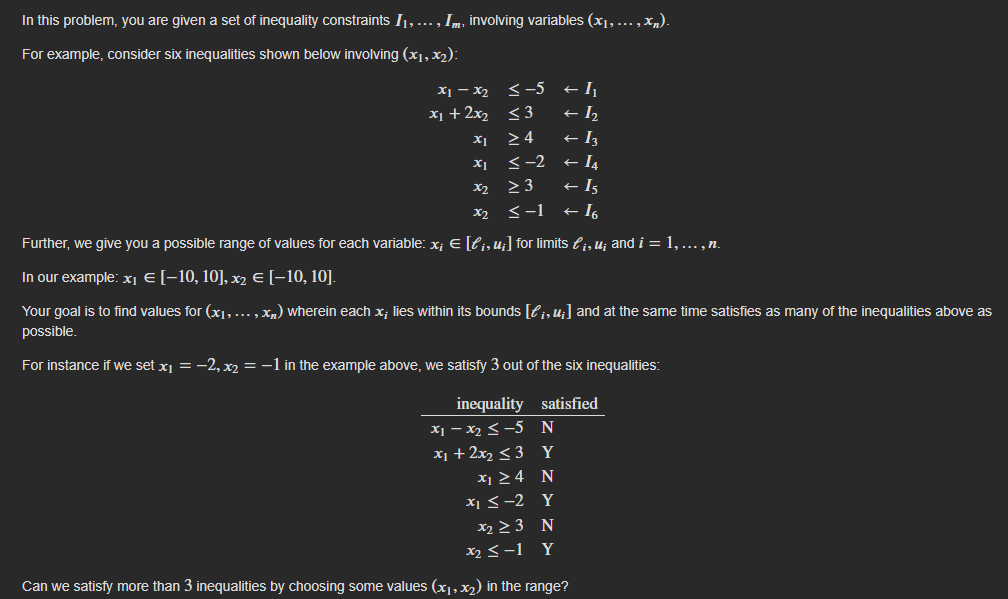

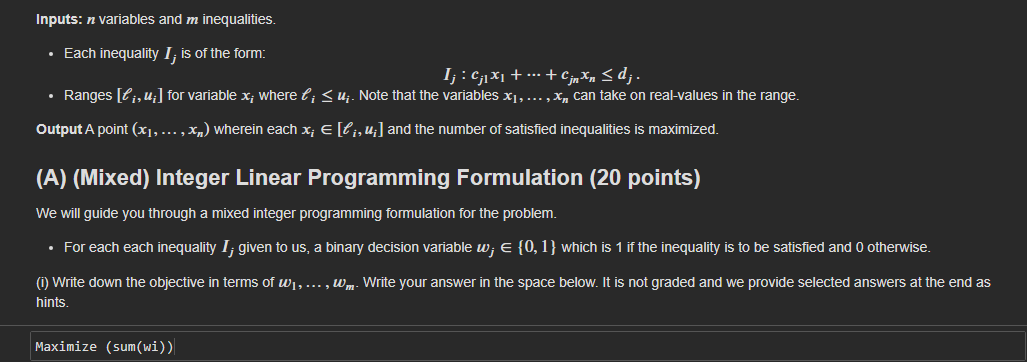

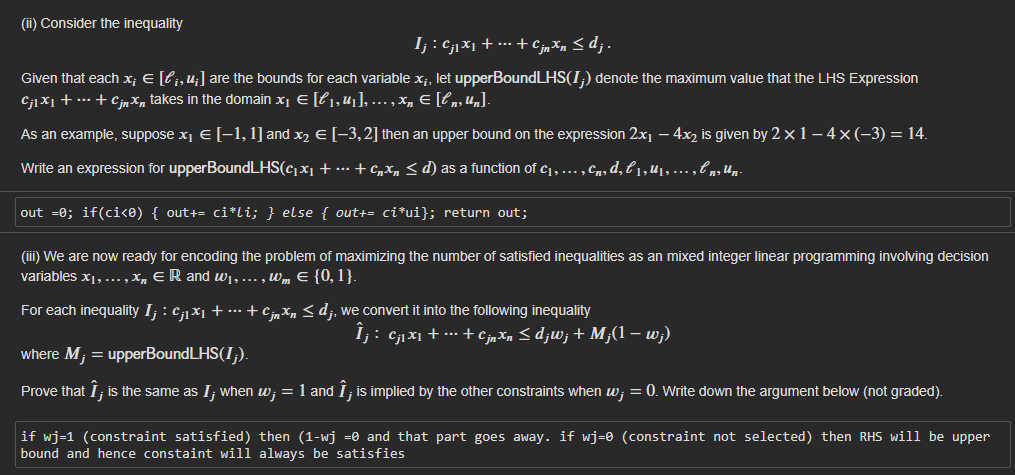

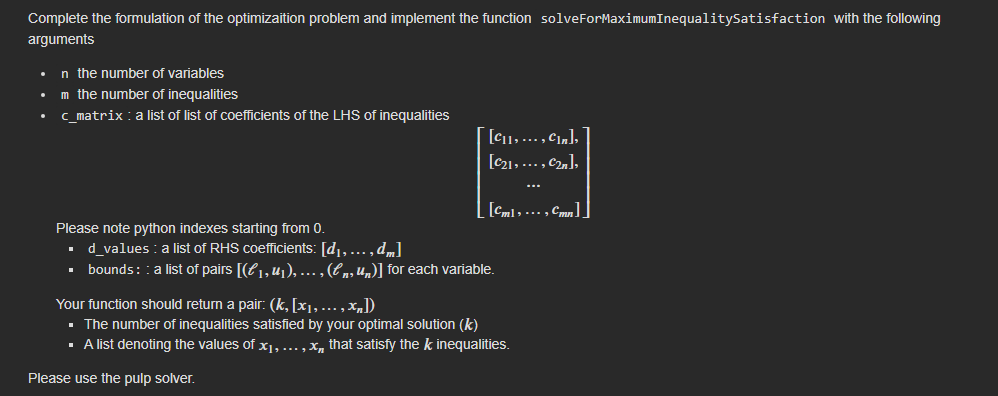


In [15]:
from pulp import *

# Here is a useful function to implement the LHS upper bound that we need for the encoding
def lhsUpperBound(c_list, bounds):
    n = len(c_list)
    assert len(bounds) == n 
    upper_bnd = sum([(cj*lj) if cj < 0 else cj*uj for (cj, (lj, uj)) in zip(c_list, bounds) ])
    return upper_bnd

def solveForMaximumInequalitySatisfaction(n, m, c_matrix, d_values, bounds):
    # always check pre-conditions: saves so much time later
    assert len(c_matrix) == m
    assert all(len(c_list) == n for c_list in c_matrix)
    assert len(d_values) == m
    assert len(bounds) == n
    assert all (lj <= uj for (lj, uj) in bounds)
    ## TODO: set up and solve the problem for satisfying the maximum number of inequalities
    # your code here
    lp_prob = LpProblem('n_problem', LpMaximize)
    # decision variables 
    lp_decision_vars = [ LpVariable(f'x{y}', lowBound = l, upBound = u, cat='Continuous') for (y,(l,u)) in enumerate(bounds)]
    # indicator variables
    lp_indicator_vars = [ LpVariable(f'w_{j}', cat='Binary') for j in range(len(d_values))]
    # lp_vars = lp_decision_vars + lp_indicator_vars

    objective_function = sum( w for w in lp_indicator_vars)
    lp_prob += objective_function

    # constraints
    for y in range(len(d_values)):
        # for (list, d_value) in zip(c_matrix,d_values):
        list = c_matrix[y]
        d_value = d_values[y]
        upper_bound = lhsUpperBound(list,bounds)
        lhs = sum([(coeff*decision_var) for (decision_var,coeff) in zip(lp_decision_vars, list)])
        rhs = d_value * lp_indicator_vars[y] + upper_bound * (1 - lp_indicator_vars[y])
        lp_prob +=  lhs <= rhs

    status = lp_prob.solve()
    assert status == constants.LpStatusOptimal, f'Unexpected non-optimal status {status}'
    for v in lp_decision_vars:
        print(v.name, "=", v.varValue)
    return (objective_function.value(), [v.varValue for v in lp_decision_vars])
            # [indicator_var for indicator_var in lp_indicator_vars])
    
    

In [16]:
def testSolution(n, m, c_matrix, d_values, bounds, x_values, k_expected):
    # always check pre-conditions: saves so much time later
    assert len(c_matrix) == m
    assert all(len(c_list) == n for c_list in c_matrix)
    assert len(d_values) == m
    assert len(bounds) == n
    assert all (lj <= uj for (lj, uj) in bounds)
    assert len(x_values) == n
    assert 0 <= k_expected <= m
    # check solution within bounds
    for i in range(n):
        (lb, ub) = bounds[i]
        assert lb <= x_values[i] <= ub, f'x_{i} fails to be within its bounds {[lb, ub]}'
    # Check how many inequalities satisfied
    num_ineqs = 0
    
    for (c_list, d) in zip(c_matrix, d_values):
        if sum([cj * xj for (cj, xj) in zip(c_list,x_values )]) <= d+1E-3:
            num_ineqs = num_ineqs + 1
    assert num_ineqs == k_expected, f' Expected number of inequalities to be sat: {k_expected} your solution satisfies: {num_ineqs} inequalities '
    print('Test Passed')
    return 
        
        
        
        

# x_1 - x_2 & \leq -5 & \leftarrow I_1 \\ 
# x_1 + 2 x_2 & \leq 3 & \leftarrow I_2 \\ 
# x_1 & \geq 4  & \leftarrow I_3\\ 
# x_1 & \leq -2  & \leftarrow I_4\\ 
# x_2 & \geq 3  & \leftarrow I_5\\ 
# x_2 & \leq -1  & \leftarrow I_6\\ 

n = 2
m = 6
c_matrix = [
    [1, -1],
    [1, 2],
    [-1, 0],
    [1, 0],
    [-1, 0],
    [1, 0]
]

d_list = [
    -5, 3, -4, -2, -3, -1
]

bounds = [(-10, 10), (-10, 10)]

(k, x_values) = solveForMaximumInequalitySatisfaction(n, m, c_matrix, d_list, bounds)
testSolution(n, m, c_matrix, d_list, bounds, x_values, 4)
print('5 points')

x0 = -10.0
x1 = -5.0
Test Passed
5 points


In [17]:

n = 3
m = 12
c_matrix = [
    [1, -1, 0],
    [1, 2, 0],
    [-1, 0, 1],
    [1, 0, 0],
    [-1, 0, 0],
    [1, 0, 0],
    [1, 0, -1],
    [0, 2, 1],
    [-1, 1, 1],
    [1, 1, 1],
    [-1, 1, 1],
    [1, 1, 1],
]

d_list = [
    -5, 3, -4, -2, -3, -1,
    -5, 3, -4, -2, -3, -1
]

bounds = [(-10, 10), (-10, 10), (-12, 12)]

(k, x_values) = solveForMaximumInequalitySatisfaction(n, m, c_matrix, d_list, bounds)
testSolution(n, m, c_matrix, d_list, bounds, x_values, 10)
print('7 points')

x0 = -2.3333333
x1 = 2.6666667
x2 = -12.0
Test Passed
7 points


In [18]:
n = 5
m = 24
c_matrix = [
    [1, -1, 0, 1, -1],
    [1, 2, 0, 0, 2],
    [-1, 0, 1, 1, 1],
    [1, 0, 0, 0, -1],
    [-1, 0, 0, -1, -1],
    [1, 0, 0, 1, 1],
    [1, 0, -1, 1, 0],
    [0, 2, 1, 0, 2],
    [-1, 1, 1, -1, 0],
    [1, 1, 1, 0, 1],
    [-1, 1, 1, 0, 0],
    [1, 1, 1, 1, 0],
    [-1, 1, 0, 1, -1],
    [1, -2, 0, 0, -2],
    [1, 0, 1, -1, -1],
    [1, 0, 1, 0, 1],
    [-1, 0, 0, 1, 1],
    [-1, 0, 0, 1, 1],
    [1, -1, 1, 1, 1],
    [0, -2, -1, 0, 2],
    [-1, -1, -1, -1, 0],
    [-1, 1, -1, 0, 1],
    [1, 0, 0, 1, 0],
    [-1, 0, -1, 0, -1],
]

d_list = [
    -5, 3, -4, -2, -3, -1,
    -5, 3, -4, -2, -3, -1,
     5, -3, 4, 2, 3, 1,
    5, -3, 4, 2, 3, 1,
    
]

bounds = [(-10, 10), (-10, 10), (-12, 12), (-1, 3), (3, 6)]

(k, x_values) = solveForMaximumInequalitySatisfaction(n, m, c_matrix, d_list, bounds)
testSolution(n, m, c_matrix, d_list, bounds, x_values, 18)
print('8 points')

x0 = 1.0
x1 = -5.0
x2 = -5.0
x3 = -1.0
x4 = 3.0
Test Passed
8 points


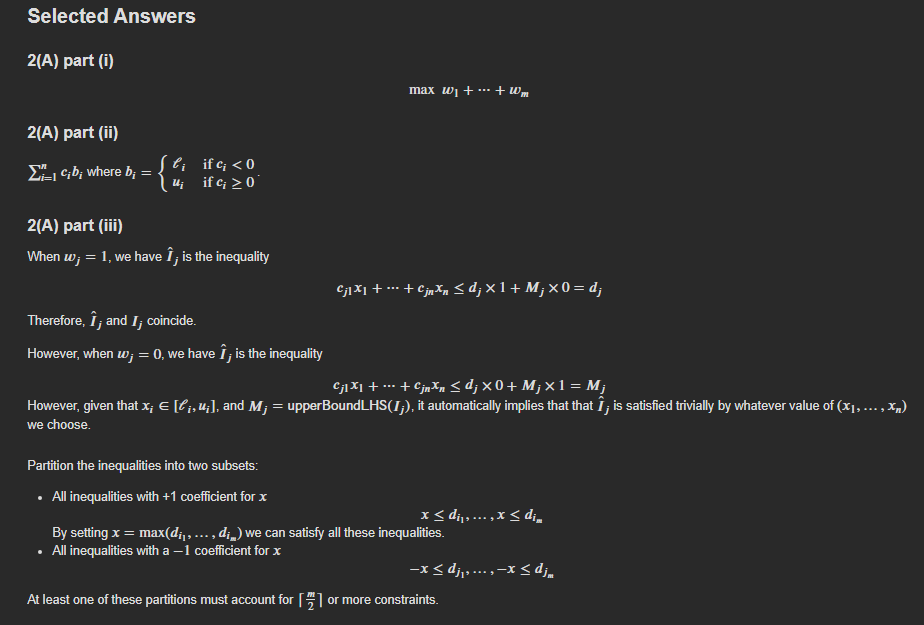
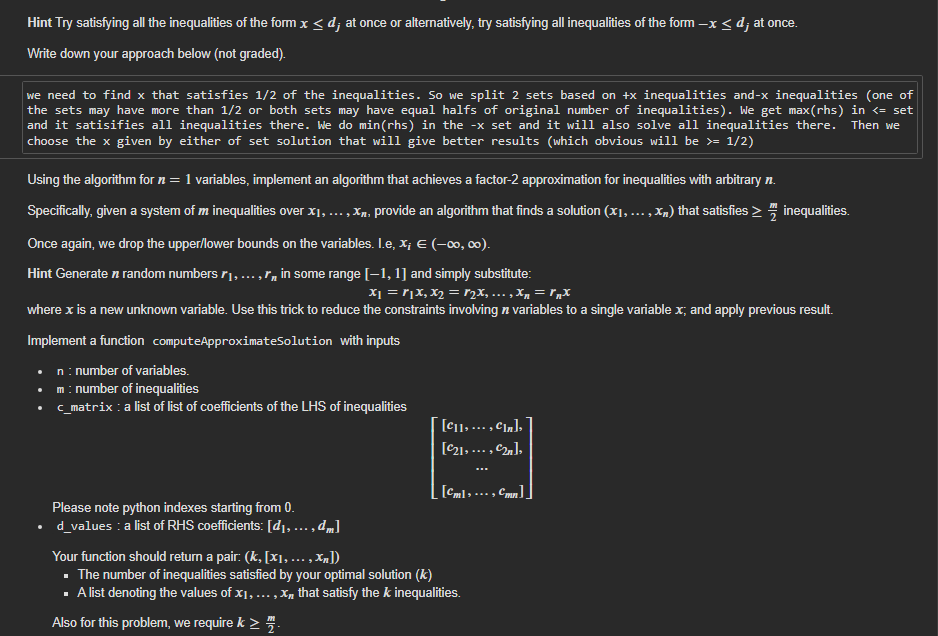
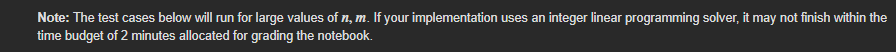

In [ ]:
from random import uniform 

def computeApproximateSolution(n, m, c_matrix, d_values):
    assert n >= 1
    assert len(c_matrix) == m
    assert all(len(c_list) == n for c_list in c_matrix)
    assert len(d_values) == m
    r_values = [uniform(-1, 1) for i in range(n)]
    # your code here
    new_coeff = [] # there will be len(c_matrix) new coefficients
    new_coeff_positive = []
    new_coeff_negative = []
    for (lhs_coeffs_of_inequality, d_value) in zip(c_matrix, d_values):
        final_lhs_coeff = 0
        for (coeff,multiplier) in zip(lhs_coeffs_of_inequality,r_values):
            final_lhs_coeff +=  coeff*multiplier
        new_coeff.append((final_lhs_coeff,d_value))
        if(final_lhs_coeff>0):
            new_coeff_positive.append((final_lhs_coeff,d_value))
        elif(final_lhs_coeff<0):
            new_coeff_negative.append((final_lhs_coeff,d_value))
        else:
            new_coeff_negative.append((final_lhs_coeff,d_value)) # this should not happen ?
    
    # check which of the 2 sets has greater length and derive x value solution for that set
    if len(new_coeff_positive) > len(new_coeff_negative):
        x = max(d_value/final_lhs_coeff for (final_lhs_coeff,d_value) in new_coeff_positive)
        return (len(new_coeff_positive), [r_value*x for r_value in r_values])
    else:
        x = min(d_value/final_lhs_coeff for (final_lhs_coeff,d_value) in new_coeff_negative)
        return (len(new_coeff_negative), [r_value*x for r_value in r_values])

    

In [ ]:
def testSolution(n, m, c_matrix, d_values, x_values):
    # always check pre-conditions: saves so much time later
    assert len(c_matrix) == m
    assert all(len(c_list) == n for c_list in c_matrix)
    assert len(d_values) == m
    assert len(x_values) == n
     # Check how many inequalities satisfied
    num_ineqs = 0
    for (c_list, d) in zip(c_matrix, d_values):
        current_sum = sum([cj * xj for (cj, xj) in zip(c_list,x_values )])
        if current_sum <= d+1E-3:
            num_ineqs = num_ineqs + 1
    assert num_ineqs >= m/2, f' Half number of inequalities to be sat: {m/2} your solution satisfies: {num_ineqs} inequalities '
    print('Test Passed')
    return 
        
        

n = 5
m = 24
c_matrix = [
    [1, -1, 0, 1, -1],
    [1, 2, 0, 0, 2],
    [-1, 0, 1, 1, 1],
    [1, 0, 0, 0, -1],
    [-1, 0, 0, -1, -1],
    [1, 0, 0, 1, 1],
    [1, 0, -1, 1, 0],
    [0, 2, 1, 0, 2],
    [-1, 1, 1, -1, 0],
    [1, 1, 1, 0, 1],
    [-1, 1, 1, 0, 0],
    [1, 1, 1, 1, 0],
    [-1, 1, 0, 1, -1],
    [1, -2, 0, 0, -2],
    [1, 0, 1, -1, -1],
    [1, 0, 1, 0, 1],
    [-1, 0, 0, 1, 1],
    [-1, 0, 0, 1, 1],
    [1, -1, 1, 1, 1],
    [0, -2, -1, 0, 2],
    [-1, -1, -1, -1, 0],
    [-1, 1, -1, 0, 1],
    [1, 0, 0, 1, 0],
    [-1, 0, -1, 0, -1],
]

d_list = [
    -5, 3, -4, -2, -3, -1,
    -5, 3, -4, -2, -3, -1,
     5, -3, 4, 2, 3, 1,
    5, -3, 4, 2, 3, 1,
    
]
(k, x_values) = computeApproximateSolution(n, m, c_matrix, d_list)
print(k)
print(x_values)

testSolution(n, m, c_matrix, d_list, x_values)
print('5 points')

13
[6.056387277355168, 1.8025030049486614, 5.3478129125197755, 3.7527456325335775, -5.50113863987293]
